In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
from colour import Color

In [3]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [4]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if (str(i)[-9:] != 'Sheet.csv') == True] #eventually master sheet created which we want this script to ignore
files = [i for i in files if (str(i)[-3:] == 'csv') == True]
files

[WindowsPath('D:/Dropbox/Summer2021 Undergrads/MTdynamics/final CSV file/Sofia_2020-08-03.csv'),
 WindowsPath('D:/Dropbox/Summer2021 Undergrads/MTdynamics/final CSV file/Sofia_2020-09-10.csv')]

In [5]:
tubulin = '[Tubulin] ' r'$(\mu M)$' #decloring names
tub = 'tub'

DCXconc = '[DCX] ' r'$(n M)$'
DCX = 'DCX'
Type = 'DCX Type'

Concentration = 'Concentration ' r'$(\mu M)$'
Length = 'Length ' r'$(\mu m)$'
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'

In [7]:
jointdate = '' #used to save all the dates, but now use the date of the most recent file

for i in files :
    dateloc = str(i).rfind("202") #changed to r.find
    date = str(i)[dateloc : dateloc+10]
    jointdate = jointdate+'_'+date

date

'2020-09-10'

In [8]:
data = pd.read_csv(files[0], encoding='utf-8')#reads csv aand stitches them
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    data = data.append(d, ignore_index=True)

In [9]:
Type_order = ['None', 'WT', 'Y64N','R76S', 'R178L', 'P191R', 'G223E']
category_Type = CategoricalDtype(Type_order, ordered=True,) #order mutants
data[Type] = data[Type].astype(category_Type)
data = data.sort_values(Type)
#FIX CONCENTRATION
data[DCXconc] = data[DCXconc].apply(lambda x: round(x*2.27))#for long time, measured conc w absorbance at 280 nm, but parameters in machine were wrong, so all here measurements at 50-100 were 2.27 times what had measured. not sure why parameters are weird. Not important just shift plot
np.sort(data[DCXconc].unique())

array([  0, 114], dtype=int64)

In [114]:
data.to_csv(path/('MasterSheet.csv'), encoding='utf-8', index=False) #storing reordered data as master sheet

In [10]:
black = '#000000' #declare colour for plotting
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
yellow = '#FFCB05'
Purple = Color(purple)
DC1color = list(Purple.range_to(Color(magenta),2))
Yellow = Color(yellow)
DC2color = list(Yellow.range_to(Color(orange),3))
print(DC1color,DC2color)

[<Color #ab4a9c>, <Color #d80b8c>] [<Color #ffcb05>, <Color #ff9f02>, <Color #ff7300>]


In [11]:
palette = [grey,cyan] + list(map(Color.get_hex,DC1color)) + list(map(Color.get_hex,DC2color)) #start grey for control, cyan is wt, then make custom palete for diff dc domain
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]

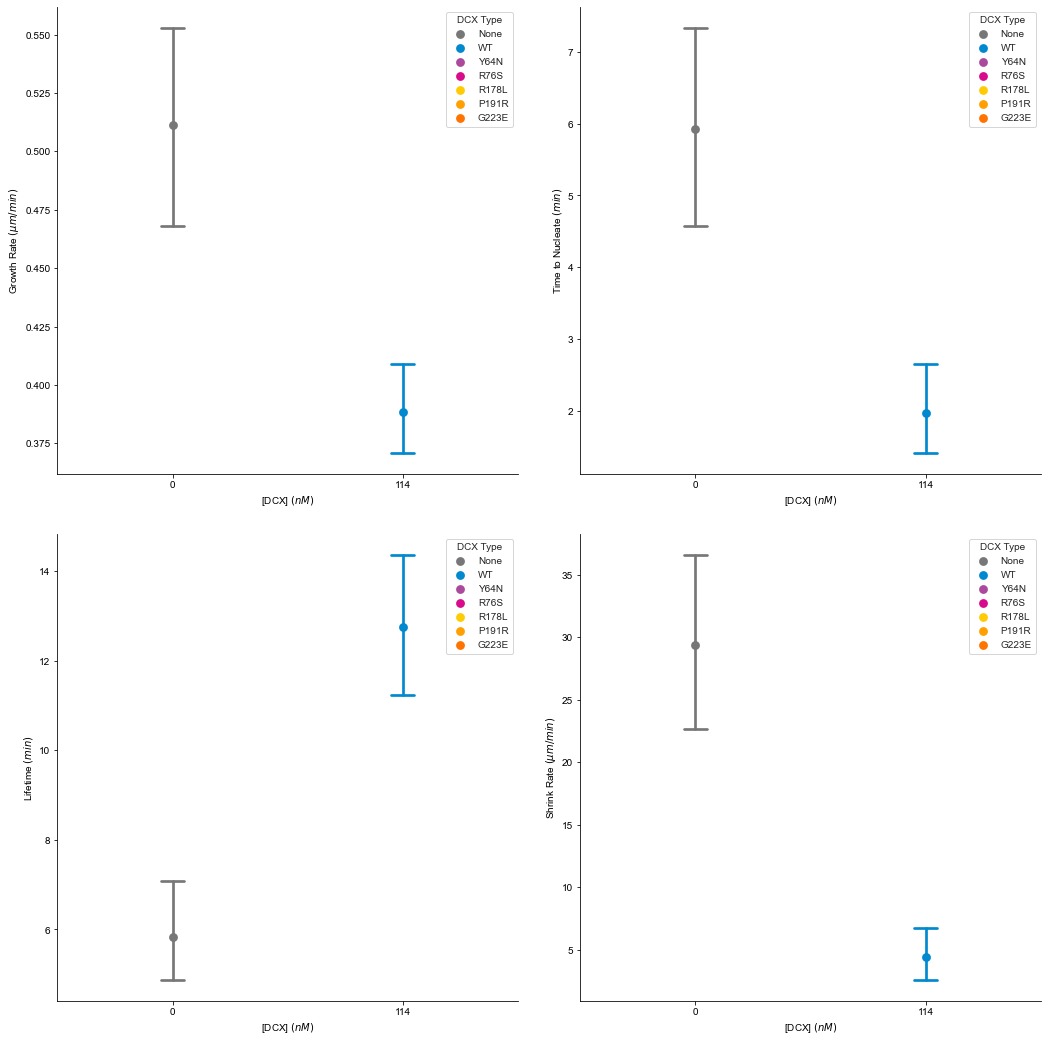

In [12]:
fig, axs = plt.subplots(2,2,figsize=(15,15)) #seaborn is the easier way to plot, does everythign with integrated functions, ex seaborn plot mean, this just to help give idea of what data looks like before fitting it, especially with trends, unfortunately stores everything and renames the ticks, ex: 0conc, 25conc, 50conc, seaborn names the data points after conc but gets rid of their coordinate at the conc
sns.set_style("ticks")                       #useful for categorical variables, ex if have cntrl and wt get named as such with each coord 0 and 1
                                            #so organizes data into plots
c = 0
for i in [0,1]:    #so each loop runs twice
    for j in [0,1]:
        sns.pointplot(x=DCXconc, y=parameters[c], #x is dcx concentration, y is other various parametes stored in loop
                        hue=Type, err_style="bars", marker='o', join=False, capsize=.1,
                        data=data[ (data[tubulin]==6)],err_kws={'capsize':10},ci=95 , palette=palette,ax=axs[i][j]) # so in first loop 00 so top left
                        #fixes tubulin conc to make easier, confidence interval is 95
                        #mat plot lib has normal plots but can also do in axis, and the commands slightly different, axis beter because allows you to access each frame within, easier to interate
        c += 1
        
sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()
plt.savefig(path/('tub6uM_DCX-variable'+date+'.pdf'))
plt.savefig(path/('tub6uM_DCX-variable'+date+'.png'))

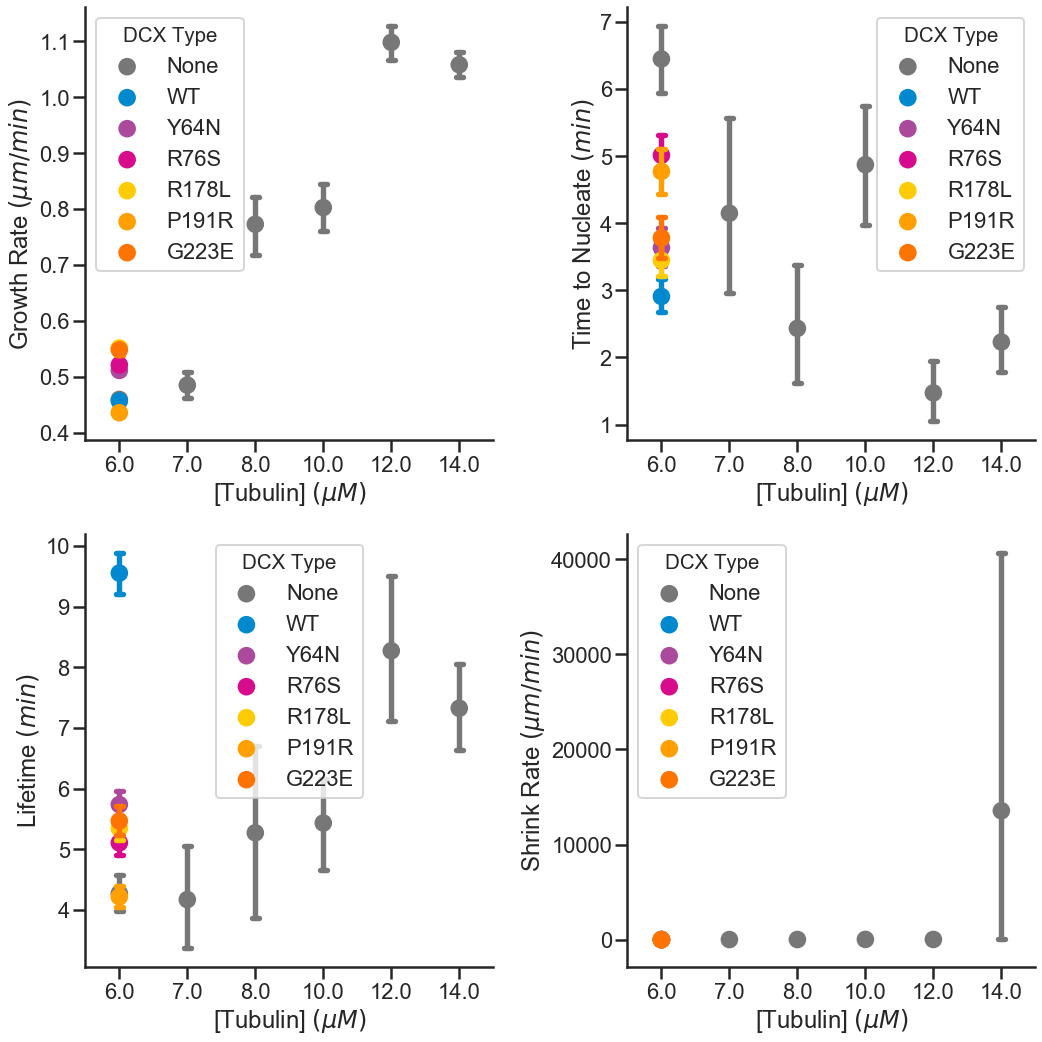

In [141]:
fig, axs = plt.subplots(2,2,figsize=(15,15)) #for diff tubulin conc,  
sns.set_style("ticks")

c = 0
for i in [0,1]:
    for j in [0,1]:
        sns.pointplot(x=tubulin, y=parameters[c],
                        hue=Type, style = DCXconc , err_style="bars", marker='o', join=False, capsize=.1,
                        data=data,err_kws={'capsize':10},ci=95 , palette=palette,ax=axs[i][j])
        c += 1
        
sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()
plt.savefig(path/('plots'+date+'.pdf'))
plt.savefig(path/('plots'+date+'.png'))

# Fitting Data #

In [13]:
def gaussian(x, mu, sig): #aka normal
    return (np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.))) )/(sig*np.sqrt(2*np.pi))

def exponential(x, scale):
    return ((np.exp(-x/scale) )/(scale))

def gamma(x, shape, scale): #multi-step exponential if shape=1 then gamme is exponential 
    return (np.power(x,shape-1)*np.exp(-x/ scale))/(sp.special.gamma(shape) * np.power(scale,shape))


In [14]:
def make_hist(data, parameter, tubconc, dcxtype, dcxconc) : 
    
    selectdata = data[(data[tubulin]==tubconc)&(data[Type]==dcxtype)&(data[DCXconc]==dcxconc)] #selecting right data you want
    
    if parameter == GrowthRate : #needs diff bin rate bc microns per minute, everyintng else is in seconds
        maxbin = 1.5
        binsize = 0.05
#     elif parameter == ShrinkageRate :
#         maxbin = 15
#         binsize = 0.1
    else:
        maxbin = 30
        binsize = 1
        
    n, bins, patches = plt.hist(selectdata[parameter], bins=np.arange(0, maxbin + binsize, binsize), density=True);
    plt.clf() #plots it 
       
    return n, bins #n is value each bin has( the y of the density), bins is x, already gave but double check

In [15]:
def equation_fit(data, parameter):
    
    if (parameter ==  GrowthRate) | (parameter == ShrinkageRate) :
        equation = gaussian
    elif parameter == TimeToNucleate :
        equation = exponential
    elif parameter == Lifetime : #slight variation because the shape has a hard time fitting with optomize fit
        equation = gamma
        
    results = pd.DataFrame(columns=[] , index=[]) #completely empty data frame
    
    for tubconc in data[tubulin].unique(): #for loop for all diff tubu conc, dcx conc, dcx type, everytime have new data fits all new data, more efficient way is to add to whatt already have, later
        for dcxtype in data[Type].unique():
            for dcxconc in data[DCXconc].unique():
                
                n, bins =  make_hist(data, parameter, tubconc, dcxtype, dcxconc)   #runs fx, extracts x,y   
                
                if np.isnan(np.sum(n)) == True:# to handle if get a null value from a histogram, ignore the rest of the loop if get null from histogram
                    continue

                if equation == gamma :
                    coeff, var_matrix = sp.optimize.curve_fit(equation,bins[:-1],n,[2,1])#the 2,1 for shape parameter start iterating at 2 instead of one so no issues as it wobbles back and forth
                else :
                    coeff, var_matrix = sp.optimize.curve_fit(equation,bins[:-1],n) #op curve fit function within python tries to fit dat to equation, does same idea as linear fit (but NOT linear fit)
                    #coefficient for gaussient the coefficient are the mean and std dev, after does fit spits out the mean and std deve best to fit the data, just for gaussian, for exponential only has 1, gamma has 2 coeffiencts, gives coefficients depending on equation
                variance = np.diagonal(var_matrix) #Refer [3] # how much the fit fo the equation is away from data
                SE = np.sqrt(variance) #Refer [4] #sum diagonal then do root sqr, so fit error

            #======Making a data frame========
                results0 = pd.DataFrame(columns=[] , index=[]) #initialize empty for each condition, subsequent concatenation
                for k in np.arange(0,len(coeff)):#for each coeficient
                    header = [np.array([parameter]),np.array(['Coefficient '+ str(k)])]
                    r0 = pd.DataFrame([coeff[k],SE[k]], index=(['Value','SE']),columns= header)#minipandas for every a given coefficient and puts in pandas for specific condition
                    results0 = pd.concat([results0, r0], axis=1, sort=False) #concatenate minipandas in to the general condition panadas #this for loop only builds data base of coefficients

                results0[tubulin] = tubconc #adding a column for a set of parameters #these lines add conditions values to the datafram full of coefficient values
                results0[Type] = dcxtype
                results0[DCXconc] = dcxconc

                results = pd.concat([results, results0], sort=False) #add above dataframe to the master, for 1 conditions, 1 parameter that you choose(ex growth rate) and the three forloops cause to go through all the conditions

    return results

In [16]:
newmydir = path/('fitdata') #put folder with fit data in folder with CSVs so dont' mix
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('D:/Dropbox/Summer2021 Undergrads/MTdynamics/final CSV file/fitdata')

In [17]:
GrowthRateFit = equation_fit(data, GrowthRate); #calls function for each parameter
TimeToNucleateFit = equation_fit(data, TimeToNucleate);
LifetimeFit = equation_fit(data, Lifetime);
ShrinkageRateFit = equation_fit(data, ShrinkageRate); #when run cell might give scary box about invalid value, not to worry the code is programmed to handle it

C:\Users\brouhardlab\anaconda3\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
C:\Users\brouhardlab\anaconda3\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
C:\Users\brouhardlab\anaconda3\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
C:\Users\brouhardlab\anaconda3\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
<ipython-input-13-539caa146321>:8: RuntimeWarning: divide by zero encountered in power
  return (np.power(x,shape-1)*np.exp(-x/ scale))/(sp.special.gamma(shape) * np.power(scale,shape))
C:\Users\brouhardlab\anaconda3\lib\site-packages\numpy\lib\histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  retur

<Figure size 432x288 with 0 Axes>

In [18]:
GrowthRateFit = GrowthRateFit.rename(columns={'Coefficient 0': 'Mean'}) #reorganizes everything and putting all the parameters togeather, 
TimeToNucleateFit = TimeToNucleateFit.rename(columns={'Coefficient 0': 'Mean'})
ShrinkageRateFit = ShrinkageRateFit.rename(columns={'Coefficient 0': 'Mean'})

LifetimeCoeff0 = LifetimeFit[Lifetime]['Coefficient 0'].loc['Value'].values #mean is product of both coefficients for lifetime so thats's why extra code
LifetimeCoeff1 = LifetimeFit[Lifetime]['Coefficient 1'].loc['Value'].values
LifetimeSE0 = LifetimeFit[Lifetime]['Coefficient 0'].loc['SE'].values
LifetimeSE1 = LifetimeFit[Lifetime]['Coefficient 1'].loc['SE'].values
LifetimeMean = LifetimeCoeff0*LifetimeCoeff1
LifetimeSE = LifetimeCoeff0*LifetimeSE1 + LifetimeCoeff1*LifetimeSE0 #propagating errors in bulky way, if differentiate function and sum up the functions (ex. partial deriv calculus)

LifetimeMeanDF = pd.DataFrame(columns=[] , index=[]) #add extra column for mean just calculated 
header = [np.array([Lifetime]),np.array(['Mean'])]  
for i in np.arange(0,len(LifetimeMean)):
    r0 = pd.DataFrame([LifetimeMean[i],LifetimeSE[i]], index=(['Value','SE']),columns= header)
    LifetimeMeanDF = pd.concat([LifetimeMeanDF, r0], sort=False)

ResultFit = pd.concat([GrowthRateFit, TimeToNucleateFit,LifetimeFit,LifetimeMeanDF,ShrinkageRateFit], axis=1, sort=False)#concatenate paramets toeather 
ResultFit = ResultFit.loc[:,~ResultFit.columns.duplicated()]

ResultFit.to_csv(newmydir/('ResultFit_'+date+'.csv'), encoding='utf-8', index=False) #saviogn #in output coefficient 1 is std dev for growth and shrinkage because those are gaussians, for coefficent 0,1 next to each other those are the shape and scale for the lifetime
ResultFit

Growth Rate $(\mu m / min)$               [Tubulin] $(\mu M)$ DCX Type  \
                             Mean Coefficient 1                                
Value                    0.487831      0.078625                 6.0     None   
SE                       0.007055      0.005760                 6.0     None   
Value                    0.362670      0.064043                 6.0       WT   
SE                       0.003029      0.002473                 6.0       WT   

      [DCX] $(n M)$ Time to Nucleate $(min)$ Lifetime $(min)$                \
                                        Mean    Coefficient 0 Coefficient 1   
Value             0                 5.479940         2.251828      2.047470   
SE                0                 0.428405         0.278080      0.313135   
Value           114                 2.125111         2.877630      4.774849   
SE              114                 0.105490         0.697078      1.402617   

                 Shrink Rate $(\mu m / min)$                
            Mean                        Mean Coefficient 1  
Value   4.610551                   11.931167      5.850917  
SE      1.274485                    1.585507      1.309900  
Value  13.740250                    0.947653      0.754475  
SE      7.364653                    0.044504      0.031714

#  PLOT DATA  #

In [19]:
def filter_variable(variable, filtername, filtervalue,data):   #becuase complex panda need function to extract easily 
    x = data[data[filtername] == filtervalue][variable].loc['Value']
    if isinstance(x, (np.ndarray)) == True :
        x = x.values
    return x

def filter_parameter(parameter, moment , filtername, filtervalue, value,data):  
    x = data[data[filtername] == filtervalue][parameter][moment].loc[value]
    if isinstance(x, (np.ndarray)) == True  :
        x = x.values
    return x

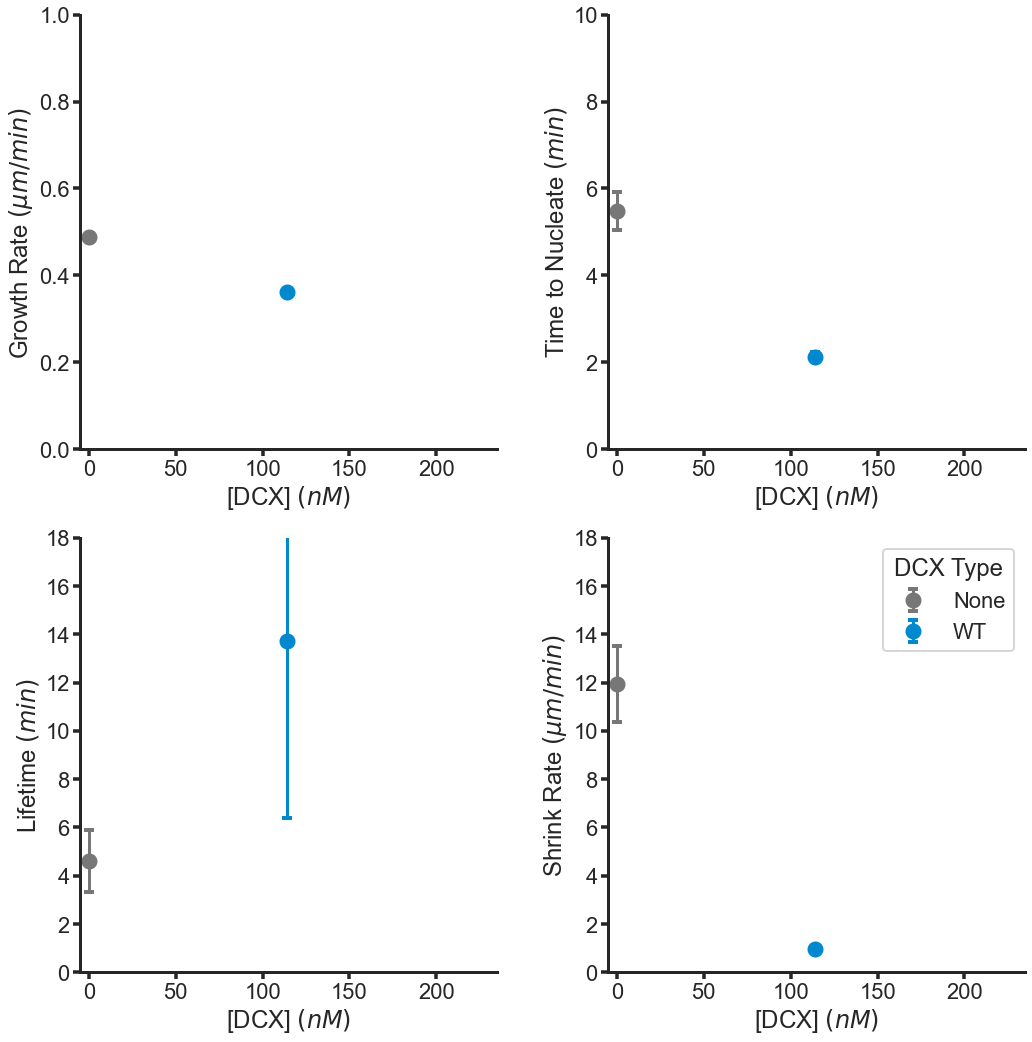

In [20]:
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate] #same plots as with sns but with mat plot lib with the mean of the function as oppposed to the mean of the data
titles = ('Growth','Nucleation','Lifetime','Shronkage Rate')
ylables = (GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate)

scattersize = 12
cap = 5

fig, ax = plt.subplots(2,2,figsize=(15,15))
#     plt.suptitle('Fitted pooled data', fontsize=30)

count = 0
for dcxtype in data[Type].unique():

    x = filter_variable(DCXconc, Type, dcxtype,ResultFit[ResultFit[tubulin]==6])
    
    c=0
    for i in np.arange(len(ax)):
        for j in np.arange(len(ax)):

            y = filter_parameter(parameters[c], 'Mean' , Type, dcxtype , 'Value',ResultFit[ResultFit[tubulin]==6])
            yerr = filter_parameter(parameters[c], 'Mean' , Type, dcxtype , 'SE', ResultFit[ResultFit[tubulin]==6])

            ax[i][j].errorbar(x , y , yerr= yerr , fmt='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,elinewidth=3,color=palette[count])

            c += 1
    count += 1

ax[0][0].set_ylim(0,1)
ax[1][0].set_ylim(0,18)
ax[0][1].set_ylim(0,10)
ax[1][1].set_ylim(0,18)

count = 0
for i in np.arange(len(ax)):
    for j in np.arange(len(ax)):
    
        ax[i][j].set_xlim(-5,235)
        ax[i][j].set_xlabel(DCXconc)
        ax[i][j].set_xticks(np.arange(0, 235, 50))
        ax[i][j].set_ylabel(ylables[count])
        ax[i][j].spines['right'].set_visible(False)
        ax[i][j].spines['top'].set_visible(False)
        ax[i][j].spines['left'].set_lw(3)
        ax[i][j].spines['bottom'].set_lw(3)
        ax[i][j].tick_params(axis='both', width = 3.5, length = 7)
        #ax[i][1].legend((Type_order),loc='upper right',title='DCX Type')
        #ax[i][j].set_title(titles[count])
        
        count += 1

ax[i][j].legend((Type_order),loc='upper right',title='DCX Type')
#fig.suptitle('[Tubulin] ' r'$= 6 \mu M$')
plt.tight_layout()
#plt.savefig(path.parents[0]/('joint_graphsFit_'+jointdate+'.png'))
plt.savefig(newmydir/('joint_graphsFit_ctetubulin_'+date+'.pdf'))

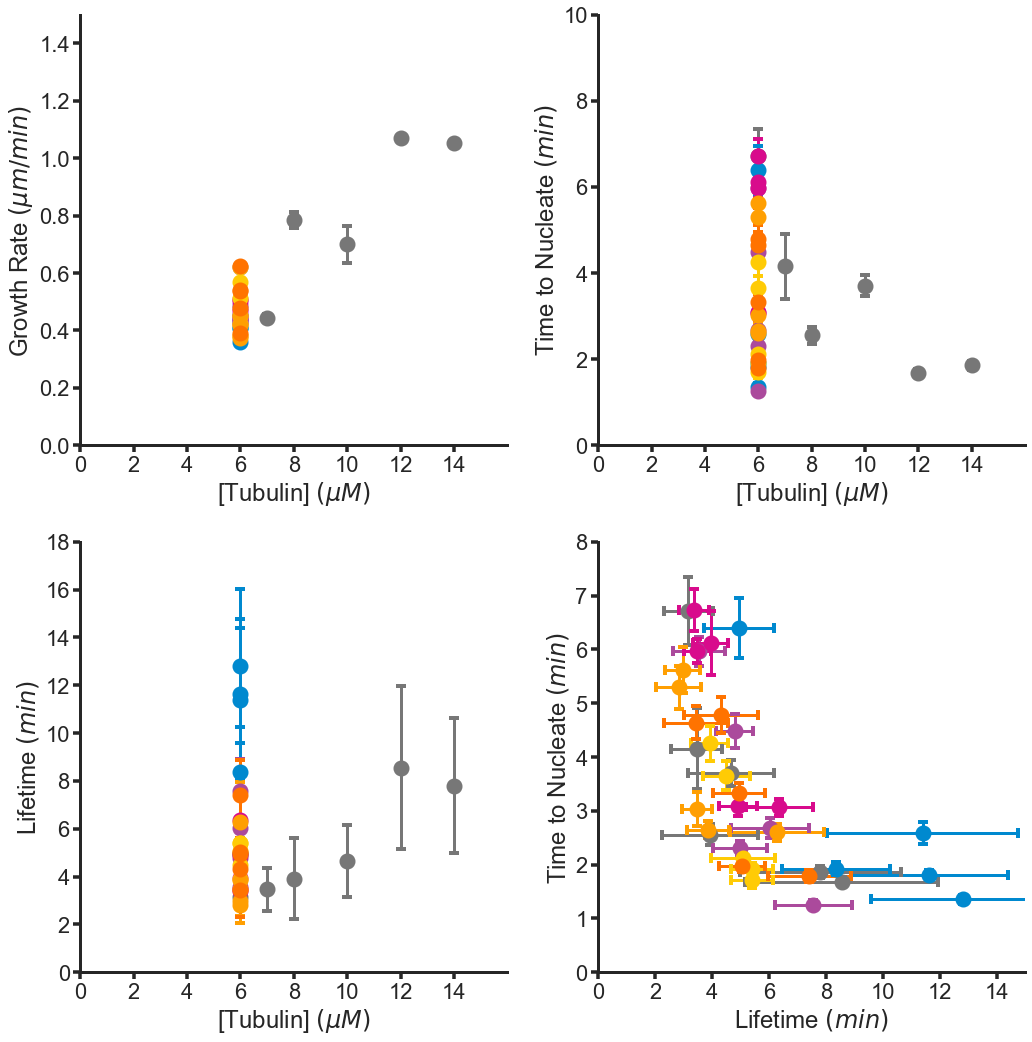

In [143]:
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]
titles = ('Growth','Nucleation','Lifetime','Correlation')
ylables = (GrowthRate,TimeToNucleate,Lifetime,TimeToNucleate)

scattersize = 12
cap = 5

fig, ax = plt.subplots(2,2,figsize=(15,15))
#     plt.suptitle('Fitted pooled data', fontsize=30)

count = 0
for dcxtype in data[Type].unique():
    
    x = filter_variable(tubulin, Type, dcxtype,ResultFit)
    c=0
    for i in np.arange(len(ax)):
        for j in np.arange(len(ax)):
            
            if i == j == 1:
             continue

            y = filter_parameter(parameters[c], 'Mean' , Type, dcxtype , 'Value',ResultFit)
            yerr = filter_parameter(parameters[c], 'Mean' , Type, dcxtype , 'SE', ResultFit)

            ax[i][j].errorbar(x , y , yerr= yerr , fmt='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,elinewidth=3,color=palette[count])
            c += 1
    
    ax[1][1].errorbar(filter_parameter(Lifetime, 'Mean' , Type, dcxtype , 'Value',ResultFit), filter_parameter(TimeToNucleate, 'Mean' , Type, dcxtype , 'Value',ResultFit),
                      xerr=filter_parameter(Lifetime, 'Mean' , Type, dcxtype , 'SE',ResultFit), yerr=filter_parameter(TimeToNucleate, 'Mean' , Type, dcxtype , 'SE',ResultFit),
                      markeredgewidth=4,elinewidth=3,fmt='o', markersize=scattersize,capsize = cap,color=palette[count])
    
    count += 1

ax[0][0].set_ylim(0,1.5)
ax[1][0].set_ylim(0,18)
ax[0][1].set_ylim(0,10)
ax[1][1].set_ylim(0,8)

count = 0
for i in np.arange(len(ax)):
    for j in np.arange(len(ax)):
    
        ax[i][j].set_xlim(0,16)
        ax[i][j].set_xlabel(tubulin)
        ax[i][j].set_xticks(np.arange(0, 16, 2))
        ax[i][j].set_ylabel(ylables[count])
        ax[i][j].spines['right'].set_visible(False)
        ax[i][j].spines['top'].set_visible(False)
        ax[i][j].spines['left'].set_lw(3)
        ax[i][j].spines['bottom'].set_lw(3)
        ax[i][j].tick_params(axis='both', width = 3.5, length = 7)
        #ax[i][1].legend(('None','WT','P191R'),loc='upper right',title='DCX Type')
        #ax[i][j].set_title(titles[count])
        
        count += 1

ax[1][1].set_xlim(0,15)
ax[1][1].set_xlabel(Lifetime)
ax[1][1].set_xticks(np.arange(0, 16, 2))


plt.tight_layout()
#plt.savefig(path.parents[0]/('joint_graphsFit_'+jointdate+'.png'))
plt.savefig(newmydir/('joint_graphsFit_corr_'+date+'.pdf'))

# Histogram #

In [136]:
def plot_hist(data, tubconc, dcxtype, dcxconc,color) : #likes making histograms to check that fit makes sense, read by self makes histogram and imports distribution functions from above, want to look similar
    
    selectdata = data[(data[tubulin]==tubconc)&(data[Type]==dcxtype)&(data[DCXconc]==dcxconc)]
    fig, ax = plt.subplots(2,2,figsize=(15,15))
    
    n = len(selectdata.dropna().index)
    
    c=0
    for i in np.arange(len(ax)):
        for j in np.arange(len(ax)):
            parameter = parameters[c]

            if parameter == GrowthRate :
                maxbin = 1.5
                binsize = 0.025
#             elif parameter == ShrinkageRate :
#                 maxbin = 25
#                 binsize = 0.5
            else:
                maxbin = 30
                binsize = 0.5

            ax[i][j].hist(selectdata[parameter], bins=np.arange(0, maxbin + binsize, binsize), 
                          density=True,color = color,alpha = 0.5);
            ax[i][j].set_xlabel(parameter)
            ax[i][j].set_ylabel('Probability')
            ax[1][1].set_xlim(0,maxbin)
            ax[i][j].spines['right'].set_visible(False)
            ax[i][j].spines['top'].set_visible(False)
            ax[i][j].spines['left'].set_lw(3)
            ax[i][j].spines['bottom'].set_lw(3)
            
            c += 1
    
    selectcoeff = ResultFit[ResultFit[tubulin]==tubconc]
    
    x = np.arange(0, 1.5 + 0.025, 0.025)
    mu = selectcoeff[(selectcoeff[Type] == dcxtype)&(selectcoeff[DCXconc] == dcxconc)][parameters[0]]['Mean'].loc['Value']
    sig = selectcoeff[(selectcoeff[Type] == dcxtype)&(selectcoeff[DCXconc] == dcxconc)][parameters[0]]['Coefficient 1'].loc['Value']
    ax[0][0].plot(x, gaussian(x, mu, sig),color = color, lw=4);
    
    x = np.arange(0, 30 + 0.5, 0.5)
    scale = selectcoeff[(selectcoeff[Type] == dcxtype)&(selectcoeff[DCXconc] == dcxconc)][parameters[1]]['Mean'].loc['Value']
    ax[0][1].plot(x, exponential(x, scale),color = color, lw=4);
    
    shape = selectcoeff[(selectcoeff[Type] == dcxtype)&(selectcoeff[DCXconc] == dcxconc)][parameters[2]]['Coefficient 0'].loc['Value']
    scale = selectcoeff[(selectcoeff[Type] == dcxtype)&(selectcoeff[DCXconc] == dcxconc)][parameters[2]]['Coefficient 1'].loc['Value']
    ax[1][0].plot(x, gamma(x, shape, scale),color = color, lw=4);
            
    mu = selectcoeff[(selectcoeff[Type] == dcxtype)&(selectcoeff[DCXconc] == dcxconc)][parameters[3]]['Mean'].loc['Value']
    sig = selectcoeff[(selectcoeff[Type] == dcxtype)&(selectcoeff[DCXconc] == dcxconc)][parameters[3]]['Coefficient 1'].loc['Value']
    ax[1][1].plot(x, gaussian(x, mu, sig),color = color, lw=4);
    
    legnd = str(dcxconc)+' nM'
    ax[0][1].legend(('Fit',legnd),loc='upper right',title='DCX: '+dcxtype)
    #ax[1][0].legend(('Fit',legnd),loc='upper right',title='DCX: '+dcxtype)
    
    #plt.savefig(newmydir/('joint_graphsHIST-'+dcxtype+'-'+str(dcxconc)+'.pdf'))
    
    return print(n)

223


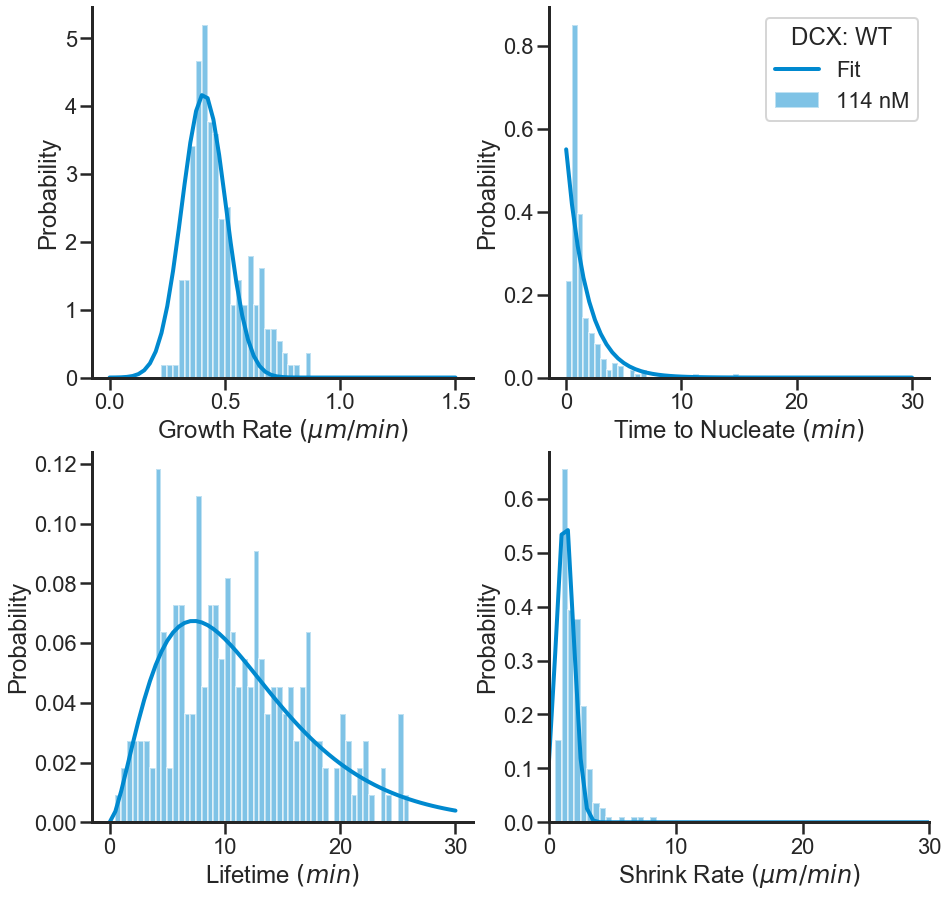

In [144]:
plot_hist(data, 6, 'WT', 114,cyan)


# Rescues #

In [130]:
def rescue_count(data): #already has rescue data from other scrpt just easier becuase don't need make any equation fits, takes 0 1 values
    
    results = pd.DataFrame(columns=[] , index=[])
    
    data.loc[pd.isnull(data[GrowthRate]), ['Rescues']] = np.NaN
    
    for tubconc in data[tubulin].unique():
        for dcxtype in data[Type].unique():
            for dcxconc in data[DCXconc].unique():
                
                selectdata = data[(data[tubulin]==tubconc)&(data[Type]==dcxtype)&(data[DCXconc]==dcxconc)]
                n =  selectdata['Rescues'].count()
                
                if n == 0:
                    continue
                    
                rv = selectdata['Rescues'].dropna().value_counts(normalize = True).to_frame()
                rescue_values = 1-rv.loc[0][0]
                

            #======Making a data frame========
                r0 = {tubulin:[tubconc], Type:[dcxtype], DCXconc:[dcxconc], 'Normalized Rescue': [rescue_values],
                     'n': [n]}
                results0 = pd.DataFrame(data=r0)
                results = pd.concat([results, results0], sort=False)

    return results

In [131]:
rescues = rescue_count(data)
rescues

,[Tubulin] $(\mu M)$,DCX Type,[DCX] $(n M)$,Normalized Rescue,n
0,12.0,None,0,0.047619,105
0,6.0,None,0,0.009756,615
0,6.0,WT,114,0.860987,223
0,6.0,WT,227,0.935714,280
0,6.0,WT,32,0.128114,281
0,6.0,WT,79,0.681564,179
0,6.0,WT,57,0.349345,229
0,6.0,Y64N,114,0.247826,230
0,6.0,Y64N,227,0.868932,206
0,6.0,Y64N,32,0.000000,209


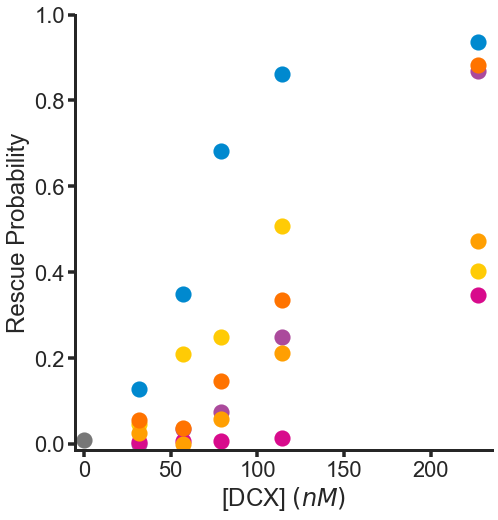

In [145]:
scattersize = 12
cap = 5

fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
#     plt.suptitle('Fitted pooled data', fontsize=30)

count = 0
for dcxtype in data[Type].unique():

    x = rescues[ (rescues[tubulin]==6) & (rescues[Type]== dcxtype)][DCXconc]

    y = rescues[ (rescues[tubulin]==6) & (rescues[Type]== dcxtype)]['Normalized Rescue']

    ax.scatter(x , y ,color=palette[count], s = 200)
    count += 1

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)
ax.tick_params(axis='both', width = 3.5, length = 7)
ax.set_ylim(-0.015,1)
ax.set_xlim(-5,235)
ax.set_xlabel( DCXconc)


#ax.set_title('Rescue')
ax.set_ylabel('Rescue Probability')


#ax.legend((Type_order),loc='upper left',title='DCX Type')
#fig.suptitle('[Tubulin] ' r'$= 6 \mu M$')
plt.tight_layout()
#plt.savefig(path.parents[0]/('joint_graphsFit_'+jointdate+'.png'))
plt.savefig(newmydir/('joint_graphsRescues.pdf'))

# Lifetime Parameters #

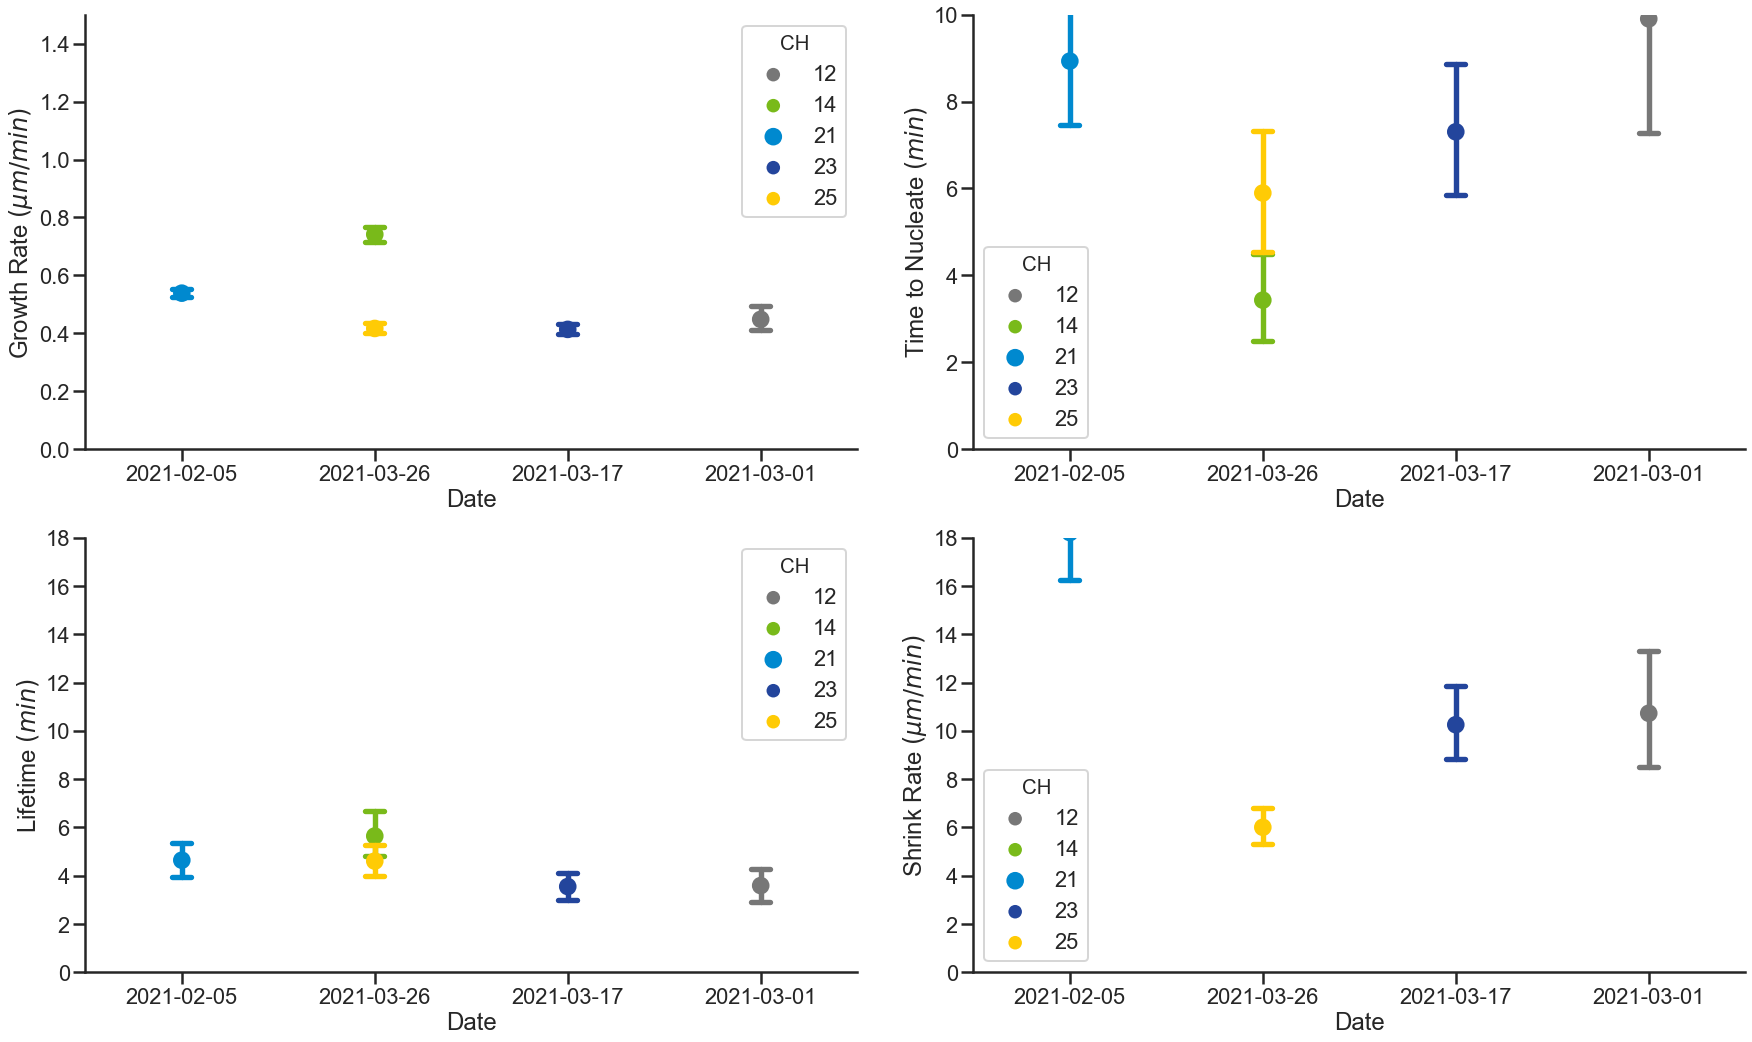

In [133]:
 selectdata = data[(data[tubulin]==6)&(data[Type]=='R76S')&(data[DCXconc]==79)] #checks that things make sense per experiments, just for internal check , not presented data 

fig, axs = plt.subplots(2,2,figsize=(25,15))
sns.set_style("ticks")

c = 0
for i in [0,1]:
    for j in [0,1]:
        sns.pointplot(x='Date', y=parameters[c],
                        hue='CH', err_style="bars", marker='o', join=False, capsize=.1,
                        data=selectdata,err_kws={'capsize':10},ci=95 , palette=palette,ax=axs[i][j])
        c += 1
axs[0][0].set_ylim(0,1.5)
axs[1][0].set_ylim(0,18)
axs[0][1].set_ylim(0,10)
axs[1][1].set_ylim(0,18)       
sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()


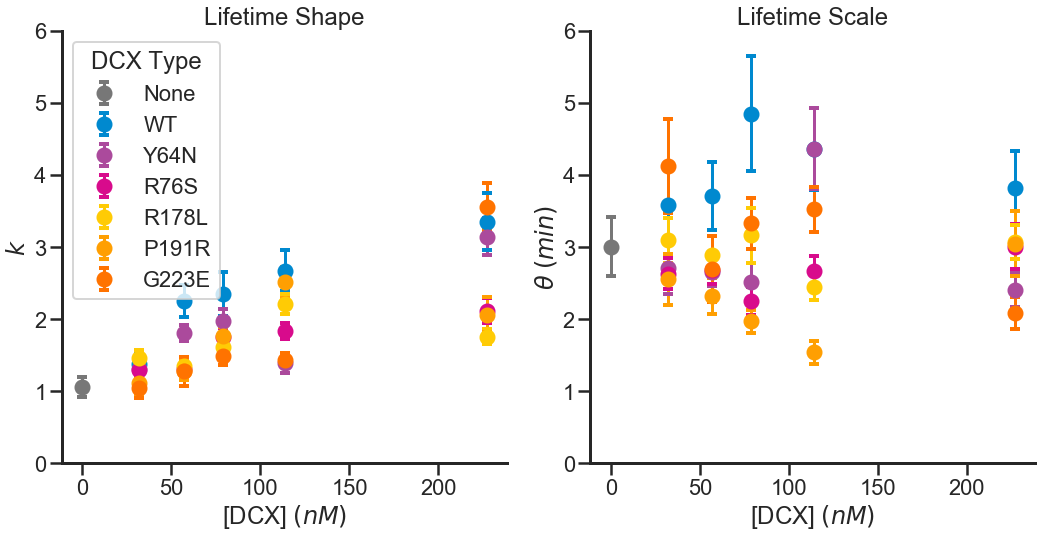

In [146]:
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]
titles = ('Growth','Nucleation','Lifetime','Shronkage Rate')
ylables = (GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate)

scattersize = 12
cap = 5

fig, ax = plt.subplots(1,2,figsize=(15,8))
#     plt.suptitle('Fitted pooled data', fontsize=30)

count = 0
for dcxtype in data[Type].unique():

    x = filter_variable(DCXconc, Type, dcxtype,ResultFit[ResultFit[tubulin]==6])
    
    c=2
    y = filter_parameter(parameters[c], 'Coefficient 0' , Type, dcxtype , 'Value',ResultFit[ResultFit[tubulin]==6])
    yerr = filter_parameter(parameters[c], 'Coefficient 0' , Type, dcxtype , 'SE', ResultFit[ResultFit[tubulin]==6])

    ax[0].errorbar(x , y , yerr= yerr , fmt='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,elinewidth=3,color=palette[count])
    
    y = filter_parameter(parameters[c], 'Coefficient 1' , Type, dcxtype , 'Value',ResultFit[ResultFit[tubulin]==6])
    yerr = filter_parameter(parameters[c], 'Coefficient 1' , Type, dcxtype , 'SE', ResultFit[ResultFit[tubulin]==6])

    ax[1].errorbar(x , y , yerr= yerr , fmt='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,elinewidth=3,color=palette[count])

       
    count += 1

for i in [0,1]:
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['left'].set_lw(3)
    ax[i].spines['bottom'].set_lw(3)
    ax[i].set_ylim(0,6)
    ax[i].set_xlabel( DCXconc)


ax[0].set_title('Lifetime Shape')
ax[0].set_ylabel( r'$k$')

ax[1].set_title('Lifetime Scale')
ax[1].set_ylabel( r'$\theta \; (min)$')


ax[0].legend((Type_order),loc='upper left',title='DCX Type')
#fig.suptitle('[Tubulin] ' r'$= 6 \mu M$')
plt.tight_layout()
#plt.savefig(path.parents[0]/('joint_graphsFit_'+jointdate+'.png'))
plt.savefig(newmydir/('joint_graphsFit_lifetimeparms.pdf'))